# **Introduction**

The goal of this notebook was to revisit our BiGRU model before submission. Since GRU_final.ipynb was our initial RNN notebook, it is recommended to go through it before to get a better understanding.

Shown below are the algorithms present on this notebook. Beforehand, the team had not considered changing the WINDOW_SIZE to a value different from 160. This required making some changes to the Submission part. Other hyperparameters were also tweaked, seeking for a better score. Finally, in order to ensure the correctness of the previous BiGRU model, the different phases were reviewed and/or reimplemented.

Since this proved to get a better score than our previous BiGRU implementation (0.8885), the next logicial steps would be automating the Grid Search. We would then recommend a K-Fold-CV to gain trust into the model. This makes it possible to train the best model on 100% of our training data with augmented trust.

Implementation
*   BiGRU Model
*   Manual grid search

Next steps
*   Automatic grid search (with WINDOW_SIZE and STRIDE)
*   K-Fold-CV (with 100% training data after evaluation)
*   Data augmentation
*   Ensemble creation

Highest Public Score
*   0.9365 (17/11/2025)




In [ ]:
# @title Running the notebook

# Please put the 'pirate_pain_train.csv', 'pirate_pain_train_labels.csv' and 'pirate_pain_test.csv' next to this notebook on Google Drive
# Change <CURRENT_DIR> to the location of this notebook
CURRENT_DIR = '/content/drive/MyDrive/INSERT_CURRENT_DIRECTORY_PATH'

# **Environment setup**

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")
%cd $CURRENT_DIR

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ANN&DL/Challenge_1/Mathieu/GRU_revisited


In [ ]:
# Display current folder
!ls "$CURRENT_DIR"

 BiGRU_REVISITED.ipynb		        submission_BiGRU_20251117_030150.csv
'Copy of BiGRU_REVISITED.ipynb'         submission_BiGRU_20251117_030500.csv
 models				        submission_BiGRU_20251117_030512.csv
 pirate_pain_test.csv		        submission_BiGRU_20251117_135511.csv
 pirate_pain_train.csv		        submission_BiGRU_20251117_151530.csv
 pirate_pain_train_labels.csv	        submission_BiGRU_20251117_152745.csv
 sample_submission.csv		        submission_BiGRU_20251117_154833.csv
 submission_BiGRU_20251117_014118.csv   submission_BiGRU_20251117_162705.csv
 submission_BiGRU_20251117_022940.csv   submission_BiGRU_20251117_163721.csv
 submission_BiGRU_20251117_023917.csv   submission_BiGRU_20251117_165348.csv
 submission_BiGRU_20251117_025026.csv   tensorboard
 submission_BiGRU_20251117_025627.csv


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


# **Data Preprocessing**

In [ ]:
# Read the training data
data = pd.read_csv("pirate_pain_train.csv", header=0)

data.head(10)

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


In [ ]:
# Read the training labels
label_df = pd.read_csv("pirate_pain_train_labels.csv", header=0)

label_df.head(10)

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,low_pain
3,3,no_pain
4,4,no_pain
5,5,no_pain
6,6,no_pain
7,7,no_pain
8,8,no_pain
9,9,no_pain


In [ ]:
# Merge training data and labels
df = data.merge(label_df, on="sample_index", how="left", validate="m:1")

print(df["label"].value_counts())
df.head(10)

label
no_pain      81760
low_pain     15040
high_pain     8960
Name: count, dtype: int64


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,two,two,two,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,two,two,two,1.135183,...,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,two,two,two,0.938017,...,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,two,two,two,1.090185,...,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5,no_pain
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5,no_pain
7,0,7,2,2,2,2,two,two,two,1.038597,...,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5,no_pain
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5,no_pain
9,0,9,0,2,2,2,two,two,two,1.054999,...,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5,no_pain


In [ ]:
# Convert data type to float32
df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

In [ ]:
# Convert categorical features to number

def map_two_to_2_else_1(x):
    return 2 if 'two' in x else 1

df["n_legs"]  = df["n_legs"].apply(map_two_to_2_else_1).astype('float32')
df["n_hands"] = df["n_hands"].apply(map_two_to_2_else_1).astype('float32')
df["n_eyes"]  = df["n_eyes"].apply(map_two_to_2_else_1).astype('float32')

In [ ]:
# Print one timestamp per pirate
df.drop_duplicates(subset="sample_index", keep="first").head(10)

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0.0,0.0,2.0,0.0,2.0,1.0,2.0,2.0,2.0,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,3.805930e-06,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
160,1.0,0.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.233603,...,1.790415e-07,3.006389e-07,6.997916e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,no_pain
320,2.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,0.170677,...,1.183228e-06,2.236364e-06,9.688514e-08,5.987389e-07,0.193762,0.115937,0.039989,0.032033,0.5,low_pain
480,3.0,0.0,1.0,2.0,2.0,0.0,2.0,2.0,2.0,0.996243,...,1.802904e-06,2.588236e-06,1.715739e-06,5.349919e-06,0.017648,0.044323,0.045728,0.041061,0.5,no_pain
640,4.0,0.0,2.0,2.0,0.0,0.0,2.0,2.0,2.0,0.972103,...,2.407151e-06,1.974214e-06,8.159604e-08,0.000000e+00,0.002939,0.015767,0.017016,0.021965,0.5,no_pain
800,5.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,1.126637,...,1.661360e-07,2.826171e-07,4.248218e-08,6.992469e-06,0.014098,0.051534,0.012429,0.051722,0.5,no_pain
960,6.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,1.101345,...,9.419276e-07,3.239535e-07,8.933957e-07,0.000000e+00,0.027001,0.144871,0.044796,0.037567,0.5,no_pain
1120,7.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.072391,...,1.772156e-07,2.982113e-07,6.608183e-08,0.000000e+00,0.027947,0.070982,0.027583,0.015155,0.5,no_pain
1280,8.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.044719,...,6.372409e-07,4.913076e-07,1.275396e-06,1.013391e-04,0.006518,0.009533,0.021116,0.036020,0.5,no_pain
1440,9.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,0.987456,...,1.803519e-07,2.622896e-07,1.462642e-08,3.784606e-06,0.005788,0.009742,0.012155,0.014311,0.5,no_pain


In [ ]:
# Define a mapping of pain values to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2,
}

df["label"] = df["label"].map(label_mapping)

In [ ]:
# Print one timestamp per pirate
df.drop_duplicates(subset="sample_index", keep="first").head(10)

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0.0,0.0,2.0,0.0,2.0,1.0,2.0,2.0,2.0,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,3.805930e-06,0.017592,0.013508,0.026798,0.027815,0.5,0
160,1.0,0.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,1.233603,...,1.790415e-07,3.006389e-07,6.997916e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,0
320,2.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,0.170677,...,1.183228e-06,2.236364e-06,9.688514e-08,5.987389e-07,0.193762,0.115937,0.039989,0.032033,0.5,1
480,3.0,0.0,1.0,2.0,2.0,0.0,2.0,2.0,2.0,0.996243,...,1.802904e-06,2.588236e-06,1.715739e-06,5.349919e-06,0.017648,0.044323,0.045728,0.041061,0.5,0
640,4.0,0.0,2.0,2.0,0.0,0.0,2.0,2.0,2.0,0.972103,...,2.407151e-06,1.974214e-06,8.159604e-08,0.000000e+00,0.002939,0.015767,0.017016,0.021965,0.5,0
800,5.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,1.126637,...,1.661360e-07,2.826171e-07,4.248218e-08,6.992469e-06,0.014098,0.051534,0.012429,0.051722,0.5,0
960,6.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,1.101345,...,9.419276e-07,3.239535e-07,8.933957e-07,0.000000e+00,0.027001,0.144871,0.044796,0.037567,0.5,0
1120,7.0,0.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.072391,...,1.772156e-07,2.982113e-07,6.608183e-08,0.000000e+00,0.027947,0.070982,0.027583,0.015155,0.5,0
1280,8.0,0.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.044719,...,6.372409e-07,4.913076e-07,1.275396e-06,1.013391e-04,0.006518,0.009533,0.021116,0.036020,0.5,0
1440,9.0,0.0,2.0,0.0,2.0,2.0,2.0,2.0,2.0,0.987456,...,1.803519e-07,2.622896e-07,1.462642e-08,3.784606e-06,0.005788,0.009742,0.012155,0.014311,0.5,0


In [ ]:
# Shuffle pirate IDs before data splitting
unique_pirates = df['sample_index'].unique()
random.seed(SEED)
random.shuffle(unique_pirates)

N_VAL_PIRATES = 99  # ~15%
N_TEST_PIRATES = 99 # ~15%

n_train_pirates = len(unique_pirates) - N_VAL_PIRATES - N_TEST_PIRATES

train_users = unique_pirates[:n_train_pirates]
val_users = unique_pirates[n_train_pirates:n_train_pirates + N_VAL_PIRATES]
test_users = unique_pirates[n_train_pirates + N_VAL_PIRATES:]

# Split the dataset into training, validation, and test sets based on pirate IDs
df_train = df[df['sample_index'].isin(train_users)]
df_val = df[df['sample_index'].isin(val_users)]
df_test = df[df['sample_index'].isin(test_users)]

print(f'Training set shape: {df_train.shape}')
print(f'Validation set shape: {df_val.shape}')
print(f'Test set shape: {df_test.shape}')

Training set shape: (74080, 41)
Validation set shape: (15840, 41)
Test set shape: (15840, 41)


In [ ]:
# Columns to be normalised
joint_cols = [f"joint_{i:02d}" for i in range(31)]

mins = df_train[joint_cols].min()
ranges = (df_train[joint_cols].max() - mins).replace(0, 1.0)

# Apply normalisation
for column in joint_cols:
    df_train[column] = (df_train[column] - mins[column]) / ranges[column]

    df_val[column] = (df_val[column] - mins[column]) / ranges[column]

    df_test[column] = (df_test[column] - mins[column]) / ranges[column]

In [ ]:
# Define WINDOW and STRIDE size

WINDOW_SIZE = 64

STRIDE = 8

In [ ]:
# Extract features as a list
features_list = [c for c in df.columns if c not in {'sample_index', 'time', 'label'} ]

print(f"Features: {features_list}")
print(f"Number of features: {len(features_list)}")

Features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'n_legs', 'n_hands', 'n_eyes', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'joint_30']
Number of features: 38


In [ ]:
def build_sequences(df, window, stride, features_list):
    # Sanity check
    assert window % stride == 0

    sequences, labels = [], []

    for id in df['sample_index'].unique():
        # Extract features and label
        features_np = df[df['sample_index'] == id][features_list].values
        label_np = df[df['sample_index'] == id]['label'].values[0]

        # Padding
        padding_len = window - len(features_np) % window
        padding = np.zeros((padding_len, len(features_list)), dtype='float32')
        features_np = np.concatenate((features_np, padding))

        # Feature building
        idx = 0
        while idx + window <= len(features_np):
            sequences.append(features_np[idx:idx + window])
            labels.append(label_np)
            idx += stride

    # Numpy arrays conversion
    sequences = np.array(sequences)
    labels = np.array(labels)

    return sequences, labels


In [ ]:
# Generate sequences and labels for all sets
X_train, y_train = build_sequences(df_train, WINDOW_SIZE, STRIDE, features_list)
X_val, y_val = build_sequences(df_val, WINDOW_SIZE, STRIDE, features_list)
X_test, y_test = build_sequences(df_test, WINDOW_SIZE, STRIDE, features_list)

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((7871, 64, 38), (7871,), (1683, 64, 38), (1683,), (1683, 64, 38), (1683,))

In [ ]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
test_ds  = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))

In [ ]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 124

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last, sampler=None):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
        sampler=sampler
    )

In [ ]:
from torch.utils.data import WeightedRandomSampler

# y_train should be a 1D array / tensor with class indices {0,1,2}
# If it's a torch tensor on GPU, move it to CPU first
if isinstance(y_train, torch.Tensor):
    y_train_np = y_train.cpu().numpy()
else:
    y_train_np = y_train

# Class counts and inverse-frequency weights
class_counts = np.bincount(y_train_np)
class_weights = 1.0 / class_counts          # e.g. [w_no_pain, w_low, w_high]

# Weight for each sample = weight of its class
sample_weights = class_weights[y_train_np]
sample_weights = torch.tensor(sample_weights, dtype=torch.float32)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break

Features batch shape: torch.Size([124, 64, 38])
Labels batch shape: torch.Size([124])


# **Model Building**

In [ ]:
# Define a summary function for RNN models
def recurrent_summary(model, input_size):

    output_shapes = {}
    hooks = []

    def get_hook(name):
        def hook(module, input, output):
            if isinstance(output, tuple):
                shape1 = list(output[0].shape)
                shape1[0] = -1

                if isinstance(output[1], tuple):
                    shape2 = list(output[1][0].shape)
                else:
                    shape2 = list(output[1].shape)

                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            else:
                shape = list(output.shape)
                shape[0] = -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    for name, module in model.named_children():
        if name in output_shapes:
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:
# Define a classifier for RNN models
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        dropout_val = dropout_rate if num_layers > 1 else 0

        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        if self.bidirectional:
            classifier_input_size = hidden_size * 2
        else:
            classifier_input_size = hidden_size

        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        rnn_out, hidden = self.rnn(x)

        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        if self.bidirectional:
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            hidden_to_classify = hidden[-1]

        logits = self.classifier(hidden_to_classify)
        return logits

rnn_model = RecurrentClassifier(
    input_size=input_shape[-1],
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 64, 128], [2, -1, 128]] 54,528         
classifier (Linear)       [-1, 3]                      387            
Total params: 54,915
Trainable params: 54,915
Non-trainable params: 0
-------------------------------------------------------------------------------


In [ ]:
 # Training configuration
LEARNING_RATE = 1e-3
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 3        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer

# Regularisation
DROPOUT_RATE = 0.1       # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 1e-4         # L2 penalty

# Set up loss function
classes, counts = np.unique(y_train, return_counts = True)
print("Class counts:", dict(zip(classes, counts)))
inv_freq = 1.0/counts
class_weights = inv_freq/inv_freq.sum() * len(classes)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(class_weights.shape)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.05
)


Class counts: {np.int64(0): np.int64(6205), np.int64(1): np.int64(1088), np.int64(2): np.int64(578)}
torch.Size([3])


# **Model Training**

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')
best_augmented_performance = float('-inf')

In [ ]:
# Define the training function for one epoch
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):

    model.train()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
# Define the validate function for one epoch
def validate_one_epoch(model, val_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
# Define the log function for RNN
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):

    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
# Define the training function for RNN
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler = None):

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    for epoch in range(1, epochs + 1):

        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                # Pass the metric being monitored (e.g., val_f1 or val_loss)
                if evaluation_metric == 'val_f1':
                    metric_to_monitor = val_f1
                elif evaluation_metric == 'val_loss':
                    metric_to_monitor = val_loss
                scheduler.step(metric_to_monitor)
                print(f"Learning rate after epoch {epoch}: {optimizer.param_groups[0]['lr']}")
            else:
              scheduler.step()

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    if writer is not None:
        writer.close()

    return model, training_history

# **Bidirectional Gated Recurrent Unit**

In [ ]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='GRU'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi_gru"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
# Scaler
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # Maximize the monitored metric (e.g., 'val_f1')
    factor=0.5,          # Reduce the learning rate by half (new_lr = lr * 0.5)
    patience=10,         # Wait for 10 epochs without improvement before reducing LR
    threshold=0.0001,    # Only significant changes (greater than threshold) count as improvement
    min_lr=1e-7          # The lowest the learning rate is allowed to go
)


-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 64, 256], [6, -1, 128]] 721,920        
classifier (Linear)       [-1, 3]                      771            
Total params: 722,691
Trainable params: 722,691
Non-trainable params: 0
-------------------------------------------------------------------------------


In [ ]:
%%time
# Train model and track training history
rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="bi_gru",
    patience=20,
    scheduler=scheduler
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_augmented_performance:
    best_model = rnn_model
    best_augmented_performance = training_history['val_f1'][-1]

Training 500 epochs...
Learning rate after epoch 1: 0.001
Epoch   1/500 | Train: Loss=1.1253, F1 Score=0.5327 | Val: Loss=1.0813, F1 Score=0.7009
Learning rate after epoch 2: 0.001
Epoch   2/500 | Train: Loss=1.0345, F1 Score=0.6594 | Val: Loss=0.9979, F1 Score=0.7512
Learning rate after epoch 3: 0.001
Epoch   3/500 | Train: Loss=0.9513, F1 Score=0.7229 | Val: Loss=0.9828, F1 Score=0.7584
Learning rate after epoch 4: 0.001
Epoch   4/500 | Train: Loss=0.8212, F1 Score=0.8107 | Val: Loss=0.9467, F1 Score=0.8330
Learning rate after epoch 5: 0.001
Epoch   5/500 | Train: Loss=0.7318, F1 Score=0.8377 | Val: Loss=0.8370, F1 Score=0.8522
Learning rate after epoch 6: 0.001
Epoch   6/500 | Train: Loss=0.6807, F1 Score=0.8371 | Val: Loss=0.7869, F1 Score=0.8100
Learning rate after epoch 7: 0.001
Epoch   7/500 | Train: Loss=0.5986, F1 Score=0.8567 | Val: Loss=0.9389, F1 Score=0.8111
Learning rate after epoch 8: 0.001
Epoch   8/500 | Train: Loss=0.5817, F1 Score=0.8717 | Val: Loss=0.8689, F1 Score=

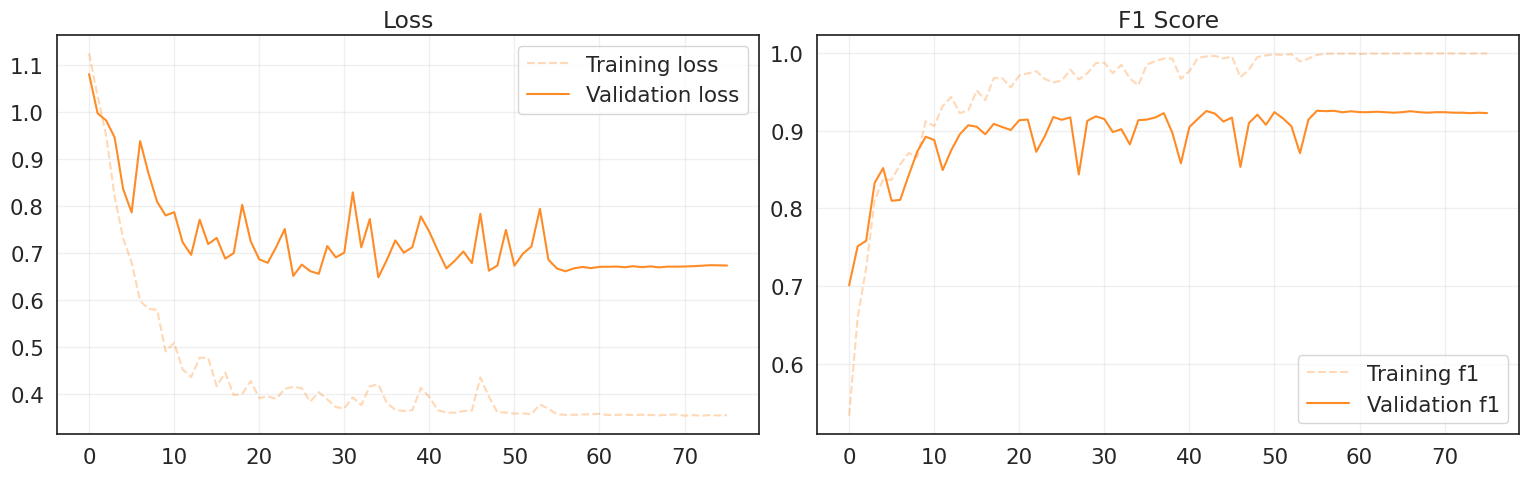

In [ ]:
# @title Plot History

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# First axis: Plot of training and validation loss
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Second axis: Plot of training and validation accuracy
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9269
Precision over the validation set: 0.9277
Recall over the validation set: 0.9269
F1 score over the validation set: 0.9261


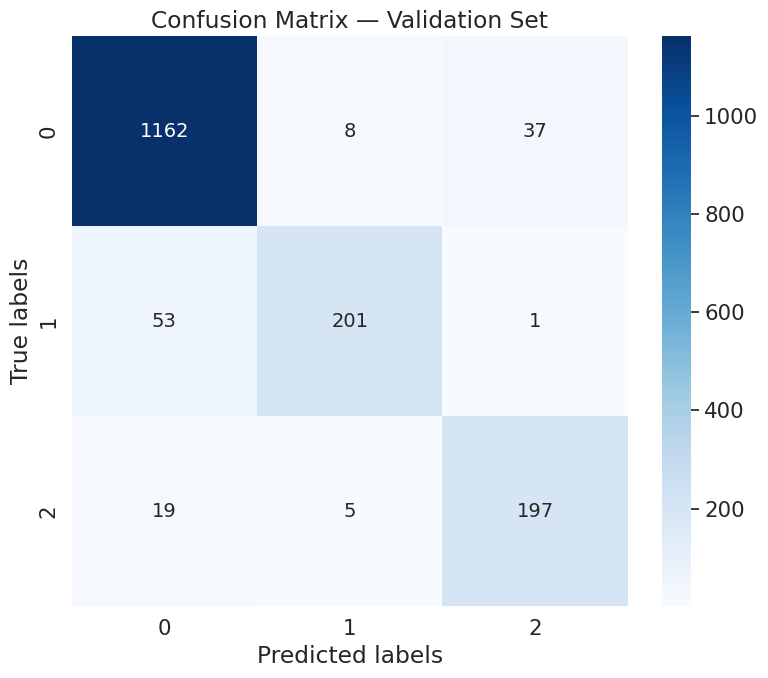

In [ ]:
# @title Plot Confusion Matrix

val_preds, val_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_preds.append(preds)
        val_targets.append(yb.numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

cm = confusion_matrix(val_targets, val_preds)

labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [ ]:
# Test model with test_loader

best_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = best_model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.9133
Test F1 Score: 0.9098
Confusion Matrix:
 [[1256    1   18]
 [  55  168   32]
 [  37    3  113]]


# **Data augmentation**

In [ ]:
def plot_real_vs_synthetic_per_feature(
    X_train, y_train,
    X_synth, y_synth,
    classes=(1, 2),
    n_samples=3,
    feature_names=None,  # NEW: List of names (must have length F)
    max_features_to_plot=6
):
    """
    Visualizes real vs synthetic time series. Generates a SEPARATE figure
    for each feature, showing N_samples of that feature side-by-side.

    X_*: [N, T, F]  (e.g. [N, 160, 41])
    y_*: [N]        (labels 0/1/2)
    """

    for cls in classes:
        # ---- Pick indices for this class ----
        real_idx = np.where(y_train == cls)[0]
        synth_idx = np.where(y_synth == cls)[0]

        if len(real_idx) < n_samples or len(synth_idx) < n_samples:
            print(f"Class {cls}: not enough samples.")
            continue

        real_idx = np.random.choice(real_idx, size=n_samples, replace=False)
        synth_idx = np.random.choice(synth_idx, size=n_samples, replace=False)

        # ---- Basic info ----
        T = X_train.shape[1]
        F = X_train.shape[2]
        n_feat = min(F, max_features_to_plot)
        time = np.arange(T)

        # Use simple indices if feature names are not provided
        if feature_names is None:
            feature_names = [f"Feature {i}" for i in range(F)]

        # === CORE CHANGE: LOOP OVER FEATURES (f) ===
        # The inner loop now becomes the main plotting loop
        for f in range(n_feat):

            feat_name = feature_names[f]

            # Create a new figure for every single feature
            fig, axes = plt.subplots(
                nrows=n_samples, ncols=2,
                figsize=(12, 2.5 * n_samples),
                sharex=True, sharey=True # Share Y-axis for better comparison
            )

            # Main Title: Name of the feature and class
            fig.suptitle(f"Class {cls} ({'low_pain' if cls==1 else 'high_pain'}) - Feature: {feat_name}",
                         fontsize=12, y=1.02)

            # Ensure axes is 2D even for n_samples=1
            if n_samples == 1:
                axes = np.array([axes])

            for row in range(n_samples):

                # --- REAL ---
                ax_real = axes[row, 0]
                seq_real = X_train[real_idx[row]]  # [T, F]

                # Plot ONLY the current feature (f)
                ax_real.plot(time, seq_real[:, f], color='darkblue', linewidth=1.5, alpha=0.8)

                ax_real.set_ylabel(f"Sample {row+1}")
                if row == 0:
                    ax_real.set_title("Real (X_train)", fontsize=10)

                # --- SYNTHETIC ---
                ax_syn = axes[row, 1]
                seq_syn = X_synth[synth_idx[row]]  # [T, F]

                # Plot ONLY the current feature (f)
                ax_syn.plot(time, seq_syn[:, f], color='darkred', linewidth=1.5, alpha=0.8)

                if row == 0:
                    ax_syn.set_title("Synthetic (X_synthetic)", fontsize=10)

            # Clean up the bottom axis labels
            for ax in axes[-1, :]:
                ax.set_xlabel("Timestep")

            plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout for suptitle
            plt.show()

In [ ]:
import numpy as np

# ==========================
# 1. Per-sequence augmentation
# ==========================

def augment_sequence(
    seq,
    jitter_sigma=0.02,
    max_shift=5,
    static_feature_indices=None,
):
    """
    Augment a single sequence with small noise and a small time shift.

    Args:
        seq: np.ndarray of shape [T, F] (e.g. [160, 41]), values in [0, 1]
        jitter_sigma: std of Gaussian noise for dynamic features (normalized scale)
        max_shift: max absolute time shift (in timesteps)
        static_feature_indices: list/array of column indices that should NOT get noise
                                (e.g. indices of pain surveys + metadata).
                                Time-shift is applied to ALL features.

    Returns:
        augmented_seq: np.ndarray of shape [T, F], in [0, 1]
    """
    seq = seq.copy()  # avoid modifying original

    T, F = seq.shape

    # Build boolean mask: True = static (no noise), False = dynamic (noise allowed)
    is_static = np.zeros(F, dtype=bool)
    if static_feature_indices is not None:
        is_static[np.array(static_feature_indices, dtype=int)] = True

    is_dynamic = ~is_static

    # 1) Add small Gaussian noise ONLY to dynamic features
    seq_noisy = seq.copy()
    '''if jitter_sigma > 0 and is_dynamic.any():
        noise = np.random.randn(T, is_dynamic.sum()) * jitter_sigma
        seq_noisy[:, is_dynamic] = seq_noisy[:, is_dynamic] + noise'''
    if np.isscalar(jitter_sigma):
      # same std for all dynamic features
      sigma_vec = np.full(F, jitter_sigma)
    else:
      # different std for different features
      sigma_vec = np.asarray(jitter_sigma)
      assert sigma_vec.shape[0] == F, "sigma_vec must have length F"

    if sigma_vec[is_dynamic].any():
        noise = np.random.randn(T, is_dynamic.sum()) * jitter_sigma
        seq_noisy[:, is_dynamic] = seq_noisy[:, is_dynamic] + noise

    # 2) Apply small time shift to the WHOLE sequence (all features)
    shift = np.random.randint(-max_shift, max_shift + 1)

    if shift > 0:
        # Shift forward: earlier frames get padded with the first frame
        shifted = np.empty_like(seq_noisy)
        shifted[shift:] = seq_noisy[:-shift]
        shifted[:shift] = seq_noisy[0]  # pad with first frame
    elif shift < 0:
        s = -shift
        shifted = np.empty_like(seq_noisy)
        shifted[:-s] = seq_noisy[s:]
        shifted[-s:] = seq_noisy[-1]    # pad with last frame
    else:
        shifted = seq_noisy

    # 3) Clip back to [0, 1] to respect normalization
    shifted = np.clip(shifted, 0.0, 1.0)

    return shifted


In [ ]:
# ==========================
# 2. Build a balanced dataset offline
# ==========================

def build_balanced_dataset(
    X_train,
    y_train,
    jitter_sigma=0.02,
    max_shift=5,
    static_feature_indices=None,
    feature_cols=None,
    target_per_class=None,
    random_seed=42,
):
    """
    Create an augmented, class-balanced dataset offline.

    Strategy:
    - Keep all original samples.
    - For each class c, if count(c) < target_per_class,
      create augmented sequences until count == target_per_class.

    Args:
        X_train: np.ndarray [N, T, F], normalized to [0, 1]
        y_train: np.ndarray [N], integer labels
        jitter_sigma: noise level for dynamic features
        max_shift: max absolute time shift
        static_feature_indices: list/array with column indices of static features
                                (no noise, but still time-shifted).
        target_per_class: dict {class_label: target_count}, or None
                          If None -> use max class count as target for all.
        random_seed: for reproducibility

    Returns:
        X_bal: np.ndarray [N_bal, T, F]
        y_bal: np.ndarray [N_bal]
    """
    np.random.seed(random_seed)

    classes, counts = np.unique(y_train, return_counts=True)
    class_counts = dict(zip(classes, counts))
    print("Original class counts:", class_counts)

    if target_per_class is None:
        max_count = counts.max()
        target_per_class = {c: max_count for c in classes}

    print("Target per class:", target_per_class)

    X_aug_list = [X_train]
    y_aug_list = [y_train]

    for c in classes:
        X_c = X_train[y_train == c]   # all sequences of class c
        n_c = X_c.shape[0]
        target = target_per_class.get(c, n_c)

        if n_c >= target:
            print(f"Class {c}: already has {n_c} >= target {target}, no augmentation.")
            continue

        n_to_add = target - n_c
        print(f"Class {c}: {n_c} -> adding {n_to_add} augmented samples")

        # Sample indices with replacement from existing class-c sequences
        idxs = np.random.choice(n_c, size=n_to_add, replace=True)

        X_synth_c = []
        for idx in idxs:
            seq = X_c[idx]  # [T, F]
            seq_aug = augment_sequence(
                seq,
                jitter_sigma=jitter_sigma,
                max_shift=max_shift,
                static_feature_indices=static_feature_indices,
            )
            X_synth_c.append(seq_aug)

        X_synth_c = np.stack(X_synth_c, axis=0)  # [n_to_add, T, F]
        y_synth_c = np.full(n_to_add, c, dtype=y_train.dtype)

        print("X number: ", X_synth_c.shape)

        X_aug_list.append(X_synth_c)
        y_aug_list.append(y_synth_c)

    plot_real_vs_synthetic_per_feature(
      X_train, y_train,
      X_synth_c, y_synth_c,
      classes=(1, 2),
      n_samples=2,
      feature_names=feature_cols,
      max_features_to_plot=len(feature_cols)
    )

    # Concatenate all
    X_bal = np.concatenate(X_aug_list, axis=0)
    y_bal = np.concatenate(y_aug_list, axis=0)

    # Shuffle
    perm = np.random.permutation(len(y_bal))
    X_bal = X_bal[perm]
    y_bal = y_bal[perm]

    # New counts
    new_classes, new_counts = np.unique(y_bal, return_counts=True)
    print("Balanced class counts:", dict(zip(new_classes, new_counts)))
    print("New dataset shape:", X_bal.shape)

    return X_bal, y_bal


In [ ]:
feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ["sample_index", "time"]
]
print(feature_cols)

# List the names of static (non-noisy) features:
static_feature_names = [
    "pain_survey_1",
    "pain_survey_2",
    "pain_survey_3",
    "pain_survey_4",
    "n_legs",
    "n_hands",
    "n_eyes",
    "pain_survey_1",
    "pain_survey_2",
    "pain_survey_3",
    "pain_survey_4"
]

# Map names -> indices
name_to_idx = {name: i for i, name in enumerate(feature_cols)}
static_feature_indices = [name_to_idx[name] for name in static_feature_names]

print("Static feature indices:", static_feature_indices)

classes, counts = np.unique(y_train, return_counts=True)
maj = counts.max()

target_per_class = {0: maj, 1: int(maj * 0.7), 2: int(maj * 0.7)}
print("Target per class:", target_per_class)

# Now build the balanced dataset
X_train_balanced, y_train_balanced = build_balanced_dataset(
    X_train,
    y_train,
    jitter_sigma=0.001,
    max_shift=5,                # shift at most ±5 frames
    static_feature_indices=static_feature_indices,
    feature_cols=feature_cols,
    target_per_class=target_per_class,      # None -> all classes to the majority size
    random_seed=42,
)


Output hidden; open in https://colab.research.google.com to view.

## Training the GRU with data augmentation

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
balanced_train_ds = TensorDataset(torch.from_numpy(X_train_balanced), torch.from_numpy(y_train_balanced))

In [ ]:
BATCH_SIZE = 124
augmented_train_loader = make_loader(balanced_train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)

In [ ]:
# Compute the class weights but manually
manual_class_weights_dict = {
    0: 1.0,  # Baseline weight for majority class (no_pain)
    1: 1.5,  # Moderate penalty for misclassifying low_pain
    2: 4.0   # Heavy penalty for misclassifying high_pain
}

sorted_weights = [manual_class_weights_dict[i] for i in sorted(manual_class_weights_dict.keys())]

augmented_class_weights = torch.tensor(sorted_weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(
    weight=augmented_class_weights,
    label_smoothing=0.1
)


In [ ]:
# Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    bidirectional=True,
    rnn_type='GRU'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

# Set up TensorBoard logging and save model architecture
experiment_name = "bi_gru"
writer = SummaryWriter("./"+logs_dir+"/"+experiment_name)
x = torch.randn(1, input_shape[0], input_shape[1]).to(device)
writer.add_graph(rnn_model, x)

# with L2 regularization
optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
# Scaler
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # Maximize the monitored metric (e.g., 'val_f1')
    factor=0.5,          # Reduce the learning rate by half (new_lr = lr * 0.5)
    patience=10,         # Wait for 10 epochs without improvement before reducing LR
    threshold=0.0001,    # Only significant changes (greater than threshold) count as improvement
    min_lr=1e-7          # The lowest the learning rate is allowed to go
)


-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (GRU)                 [[-1, 64, 256], [6, -1, 128]] 721,920        
classifier (Linear)       [-1, 3]                      771            
Total params: 722,691
Trainable params: 722,691
Non-trainable params: 0
-------------------------------------------------------------------------------


In [ ]:
%%time
# Train model and track training history
augmented_rnn_model, training_history = fit(
    model=rnn_model,
    train_loader=augmented_train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name="bi_gru",
    patience=20,
    scheduler=scheduler
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_augmented_model = augmented_rnn_model
    best_augmented_performance = training_history['val_f1'][-1]

Training 500 epochs...
Learning rate after epoch 1: 0.001
Epoch   1/500 | Train: Loss=0.7160, F1 Score=0.6274 | Val: Loss=0.9080, F1 Score=0.7276
Learning rate after epoch 2: 0.001
Epoch   2/500 | Train: Loss=0.6213, F1 Score=0.7440 | Val: Loss=1.0552, F1 Score=0.7198
Learning rate after epoch 3: 0.001
Epoch   3/500 | Train: Loss=0.5552, F1 Score=0.8054 | Val: Loss=1.4027, F1 Score=0.4844
Learning rate after epoch 4: 0.001
Epoch   4/500 | Train: Loss=0.4660, F1 Score=0.8758 | Val: Loss=0.7403, F1 Score=0.8787
Learning rate after epoch 5: 0.001
Epoch   5/500 | Train: Loss=0.4167, F1 Score=0.9150 | Val: Loss=1.1346, F1 Score=0.6356
Learning rate after epoch 6: 0.001
Epoch   6/500 | Train: Loss=0.4036, F1 Score=0.9194 | Val: Loss=0.8319, F1 Score=0.8079
Learning rate after epoch 7: 0.001
Epoch   7/500 | Train: Loss=0.3573, F1 Score=0.9475 | Val: Loss=0.7372, F1 Score=0.8794
Learning rate after epoch 8: 0.001
Epoch   8/500 | Train: Loss=0.3493, F1 Score=0.9527 | Val: Loss=0.7196, F1 Score=

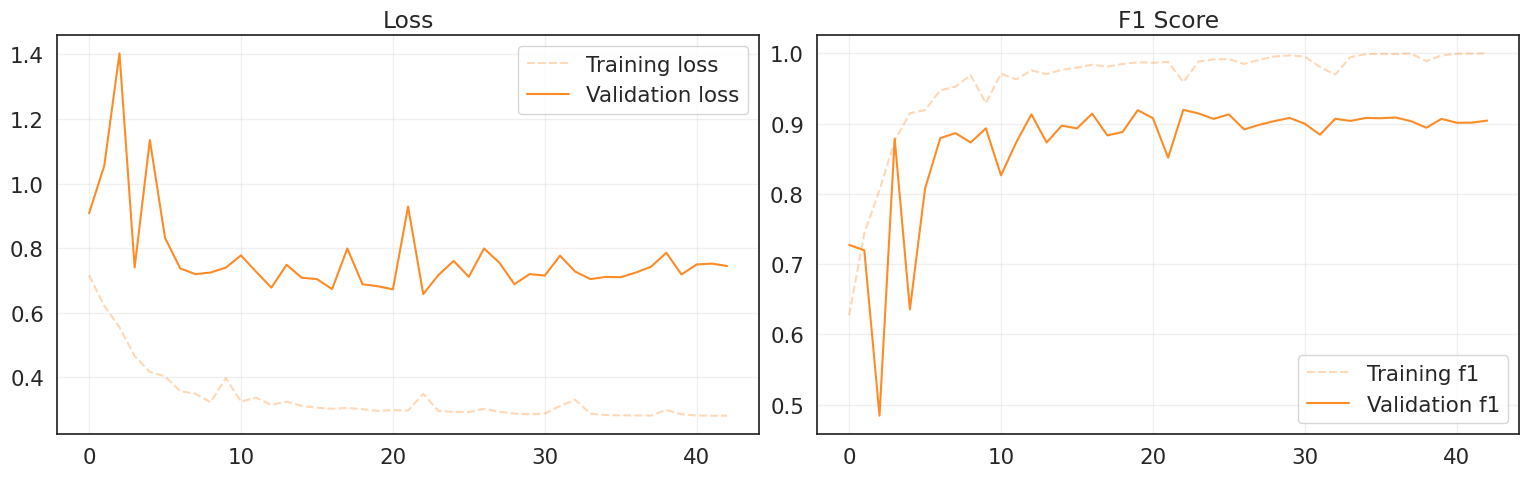

In [ ]:
# @title Plot History

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# First axis: Plot of training and validation loss
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Second axis: Plot of training and validation accuracy
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.9216
Precision over the validation set: 0.9208
Recall over the validation set: 0.9216
F1 score over the validation set: 0.9197


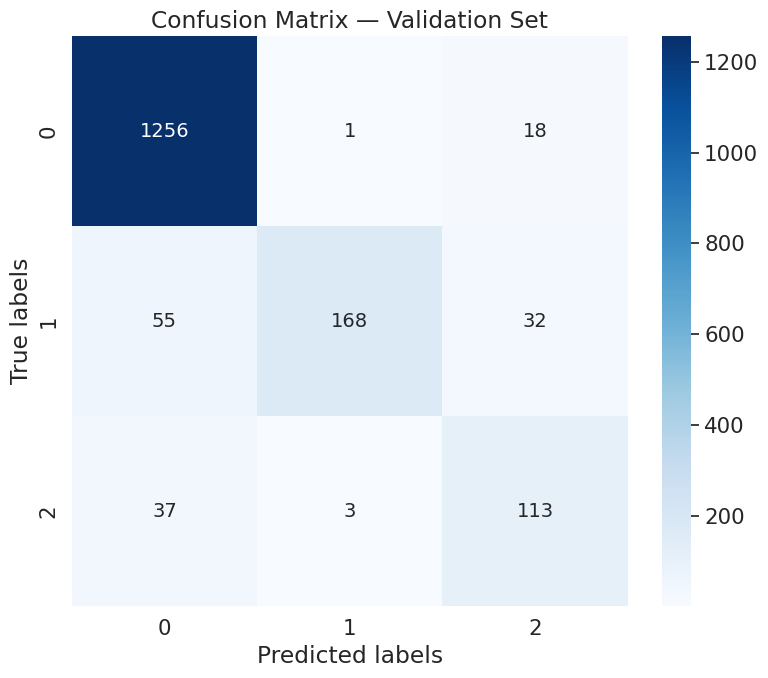

In [ ]:
# @title Plot Confusion Matrix

val_preds, val_targets = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)

        logits = rnn_model(xb)
        preds = logits.argmax(dim=1).cpu().numpy()

        val_preds.append(preds)
        val_targets.append(yb.numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')
print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

cm_augmented = confusion_matrix(val_targets, val_preds)

labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='',
            cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [ ]:
# Test model with test_loader

best_augmented_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = best_augmented_model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

Test Accuracy: 0.9049
Test F1 Score: 0.9032
Confusion Matrix:
 [[1234    9   32]
 [  54  179   22]
 [  26   17  110]]


# **Submission**

In [ ]:
# Make prediction on new test data with a trained model
def generate_predictions(file_path, model, window, stride, batch_size, model_name):

    # Read file data
    df = pd.read_csv(file_path, header=0)

    # Cast to float32
    df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)

    # Map to integer
    def map_two_to_2_else_1(x): return 2 if 'two' in x else 1
    df["n_legs"]  = df["n_legs"].apply(map_two_to_2_else_1).astype('float32')
    df["n_hands"] = df["n_hands"].apply(map_two_to_2_else_1).astype('float32')
    df["n_eyes"]  = df["n_eyes"].apply(map_two_to_2_else_1).astype('float32')

    # Normalize
    joint_cols = [f"joint_{i:02d}" for i in range(31)]
    mins = df[joint_cols].min()
    ranges = (df[joint_cols].max() - mins).replace(0, 1.0)
    for column in joint_cols:
        df[column] = (df[column] - mins[column]) / ranges[column]

    # Build sequences
    sequences = []
    sample_indices = []

    for id in df['sample_index'].unique():
        features_np = df[df['sample_index'] == id][features_list].values

        padding_len = window - len(features_np) % window
        padding = np.zeros((padding_len, len(features_list)), dtype='float32')
        features_np = np.concatenate((features_np, padding))

        idx = 0
        while idx + window <= len(features_np):
            sequences.append(features_np[idx:idx + window])
            sample_indices.append(id)
            idx += stride

    sequences = np.array(sequences, dtype='float32')

    # Create the loader
    kaggle_ds = TensorDataset(torch.from_numpy(sequences))
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    kaggle_loader = DataLoader(
        kaggle_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

    # Predict
    all_preds = []
    model.eval()
    with torch.no_grad():
        for batch in kaggle_loader:
            X_batch = batch[0].to(device)
            preds = model(X_batch)
            preds = preds.argmax(dim=1)
            all_preds.append(preds.cpu())

    all_preds = torch.cat(all_preds).numpy()

    # Create prediction dataframe
    df_pred = pd.DataFrame({
        "sample_index": sample_indices,
        "label": all_preds
    })

    # Aggregate predictions for each pirate using majority vote across windows
    df_final = df_pred.groupby("sample_index")["label"].agg(lambda x: x.value_counts().idxmax()).reset_index()

    # Reverse label mapping
    int_to_label = {
        0: "no_pain",
        1: "low_pain",
        2: "high_pain",
    }
    df_final["label"] = df_final["label"].map(int_to_label)

    # Save CSV
    output_path = os.path.join(CURRENT_DIR, f"submission_{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")
    df_final.to_csv(output_path, index=False)
    print(f"Predictions saved to {output_path}")

    return df_final



In [ ]:
# Generate a prediction CSV out of the test file
df_final = generate_predictions('pirate_pain_test.csv', best_model, WINDOW_SIZE, STRIDE, BATCH_SIZE, model_name="BiGRU")
df_final.head(10)

Predictions saved to /content/drive/MyDrive/ANN&DL/Challenge_1/Mathieu/GRU_revisited/submission_BiGRU_20251117_171903.csv


,sample_index,label
0,0.0,no_pain
1,1.0,no_pain
2,2.0,no_pain
3,3.0,no_pain
4,4.0,no_pain
5,5.0,no_pain
6,6.0,no_pain
7,7.0,no_pain
8,8.0,no_pain
9,9.0,no_pain


In [ ]:
# Generate a prediction CSV out of the test file
df_augmented_final = generate_predictions('pirate_pain_test.csv', best_augmented_model, WINDOW_SIZE, STRIDE, BATCH_SIZE, model_name="BiGRU")
df_augmented_final.head(10)

Predictions saved to /content/drive/MyDrive/ANN&DL/Challenge_1/Mathieu/GRU_revisited/submission_BiGRU_20251117_171910.csv


,sample_index,label
0,0.0,no_pain
1,1.0,no_pain
2,2.0,no_pain
3,3.0,no_pain
4,4.0,no_pain
5,5.0,low_pain
6,6.0,no_pain
7,7.0,no_pain
8,8.0,no_pain
9,9.0,no_pain


### Ensemble of plain and augmented GRU

In [ ]:
def calculate_f1_scores(cm_matrix):
    """Calculates per-class F1 scores from a confusion matrix."""
    cm_matrix = np.array(cm_matrix, dtype=np.float64)

    # Diagonal elements are True Positives (TP)
    tp = np.diag(cm_matrix)

    # Sum of the columns gives the total predictions for each class
    # Used for Precision denominator (TP + FP)
    predicted_positives = np.sum(cm_matrix, axis=0)

    # Sum of the rows gives the total true samples for each class
    # Used for Recall denominator (TP + FN)
    actual_positives = np.sum(cm_matrix, axis=1)

    # Precision: TP / (TP + FP)
    precision = tp / predicted_positives

    # Recall: TP / (TP + FN)
    recall = tp / actual_positives

    # F1 Score: 2 * (P * R) / (P + R)
    # Use np.nan_to_num to handle potential division by zero (e.g., if P+R=0)
    f1_scores = 2 * (precision * recall) / (precision + recall)

    return np.nan_to_num(f1_scores, nan=0.0) # Convert NaNs to 0 if a class has no samples

# 1. Compute per-class F1 scores for both models
f1_m1 = calculate_f1_scores(cm)
f1_m2 = calculate_f1_scores(cm_augmented)

# 2. Compute the sum of F1 scores for normalization (Element-wise)
sum_f1 = f1_m1 + f1_m2

# 3. Calculate Normalized Weights (W_i = F1_i / Sum_F1_i)
# We handle the case where the sum is zero (though unlikely with these matrices)
# For F1_M1
weight_m1_np = np.divide(f1_m1, sum_f1, out=np.zeros_like(f1_m1), where=sum_f1!=0)
# For F1_M2 (1 - W_M1 is simpler and guarantees sum=1, but direct calc is shown for clarity)
weight_m2_np = np.divide(f1_m2, sum_f1, out=np.zeros_like(f1_m2), where=sum_f1!=0)

# 4. Convert to PyTorch Tensors for use in the prediction function
weight_m1 = torch.from_numpy(weight_m1_np).float()
weight_m2 = torch.from_numpy(weight_m2_np).float()

print("--- Calculated F1 Scores ---")
print(f"Model 1 F1 Scores: {f1_m1}")
print(f"Model 2 F1 Scores: {f1_m2}")
print("\n--- Calculated Weights ---")
print(f"Weight Model 1 (W_M1): {weight_m1.tolist()}")
print(f"Weight Model 2 (W_M2): {weight_m2.tolist()}")

--- Calculated F1 Scores ---
Model 1 F1 Scores: [0.95326381 0.77826087 0.69400631]
Model 2 F1 Scores: [0.951417   0.83760684 0.8411215 ]

--- Calculated Weights ---
Weight Model 1 (W_M1): [0.500484824180603, 0.48163649439811707, 0.4520837366580963]
Weight Model 2 (W_M2): [0.49951520562171936, 0.5183634757995605, 0.5479162931442261]


In [ ]:
# Make prediction on new test data with a trained model
def generate_predictions_ensemble(file_path, model_1, model_2, weight_m1, weight_m2, window, stride, batch_size, model_name):

    # Read file data
    df = pd.read_csv(file_path, header=0)

    # Cast to float32
    df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)

    # Map to integer
    def map_two_to_2_else_1(x): return 2 if 'two' in x else 1
    df["n_legs"]  = df["n_legs"].apply(map_two_to_2_else_1).astype('float32')
    df["n_hands"] = df["n_hands"].apply(map_two_to_2_else_1).astype('float32')
    df["n_eyes"]  = df["n_eyes"].apply(map_two_to_2_else_1).astype('float32')

    # Normalize
    joint_cols = [f"joint_{i:02d}" for i in range(31)]
    mins = df[joint_cols].min()
    ranges = (df[joint_cols].max() - mins).replace(0, 1.0)
    for column in joint_cols:
        df[column] = (df[column] - mins[column]) / ranges[column]

    # Build sequences
    sequences = []
    sample_indices = []

    for id in df['sample_index'].unique():
        features_np = df[df['sample_index'] == id][features_list].values

        padding_len = window - len(features_np) % window
        padding = np.zeros((padding_len, len(features_list)), dtype='float32')
        features_np = np.concatenate((features_np, padding))

        idx = 0
        while idx + window <= len(features_np):
            sequences.append(features_np[idx:idx + window])
            sample_indices.append(id)
            idx += stride

    sequences = np.array(sequences, dtype='float32')

    # Create the loader
    kaggle_ds = TensorDataset(torch.from_numpy(sequences))
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    kaggle_loader = DataLoader(
        kaggle_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

    # Predict
    all_preds = []

    # Ensure models and weights are on the correct device and models are in eval mode
    model_1.to(device).eval()
    model_2.to(device).eval()

    # Ensure weights are float32 and on the correct device
    weight_m1 = weight_m1.to(device).float()
    weight_m2 = weight_m2.to(device).float()

    with torch.no_grad():
        for batch in kaggle_loader:
            X_batch = batch[0].to(device)

            logits1 = model_1(X_batch)
            logits2 = model_2(X_batch)

            # 🥇 Weighted Ensemble: Multiply logits by class-wise weight vectors
            # unsqueeze(0) makes the weights [1, N_classes] to broadcast across the batch [B, N_classes]
            weighted_logits1 = logits1 * weight_m1.unsqueeze(0)
            weighted_logits2 = logits2 * weight_m2.unsqueeze(0)

            # Sum the weighted logits
            avg_logits = weighted_logits1 + weighted_logits2

            # Determine the final class prediction
            preds = avg_logits.argmax(dim=1)
            all_preds.append(preds.cpu())

    all_preds = torch.cat(all_preds).numpy()

    # Create prediction dataframe
    df_pred = pd.DataFrame({
        "sample_index": sample_indices,
        "label": all_preds
    })

    # Aggregate predictions for each pirate using majority vote across windows
    df_final = df_pred.groupby("sample_index")["label"].agg(lambda x: x.value_counts().idxmax()).reset_index()

    # Reverse label mapping
    int_to_label = {
        0: "no_pain",
        1: "low_pain",
        2: "high_pain",
    }
    df_final["label"] = df_final["label"].map(int_to_label)

    # Save CSV
    output_path = os.path.join(CURRENT_DIR, f"submission_{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv")
    df_final.to_csv(output_path, index=False)
    print(f"Predictions saved to {output_path}")

    return df_final

In [ ]:
df_ensemble_final = generate_predictions_ensemble('pirate_pain_test.csv', best_model, best_augmented_model, weight_m1, weight_m2, WINDOW_SIZE, STRIDE, BATCH_SIZE, model_name="ensemble_BiGRU")
df_ensemble_final.head(10)

Predictions saved to /content/drive/MyDrive/ANN&DL/Challenge_1/Mathieu/GRU_revisited/submission_ensemble_BiGRU_20251117_172122.csv


,sample_index,label
0,0.0,no_pain
1,1.0,no_pain
2,2.0,no_pain
3,3.0,no_pain
4,4.0,no_pain
5,5.0,no_pain
6,6.0,no_pain
7,7.0,no_pain
8,8.0,no_pain
9,9.0,no_pain
